# GSM8K pass@1 plots

This notebook pulls GSM8K runs from W&B project `ai2-llm/open_instruct_internal`, extracts selected metrics from those runs, normalizes eval steps to 100-step bins, and plots pass@1 over `Step` for the requested DDP active-learning groups. The initial point at `Step == 0` comes from run `qtenf0on` and is recorded with run name `initial_eval`.

In [11]:
!uv pip install --no-config seaborn

Using Python 3.12.0 environment at: /Users/hamishivison/Programming/open-instruct/.venv
Audited 1 package in 4ms


In [12]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import wandb

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [13]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
METRICS = {
    "pass_at_1": "eval/pass_at_1",
}
PLOT_METRIC_NAME = "pass_at_1"
INITIAL_RUN_ID = "qtenf0on"
INITIAL_RUN_NAME = "initial_eval"

GROUPS = [
    "ddp_active_n8_k32",
    "ddp_active_n16_k16",
    "ddp_active_n32_k8",
    "ddp_active_n64_k4",
]
GROUP_LABELS = {
    "ddp_active_n8_k32": "N=8, K=32",
    "ddp_active_n16_k16": "N=16, K=16",
    "ddp_active_n32_k8": "N=32, K=8",
    "ddp_active_n64_k4": "N=64, K=4",
}

STEP_BIN = 100
MAX_STEP = 2000
REPO_OR_NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = (REPO_OR_NOTEBOOK_DIR if REPO_OR_NOTEBOOK_DIR.name == "notebooks" else REPO_OR_NOTEBOOK_DIR / "notebooks") / "figures"

api = wandb.Api(timeout=90)

wandb: Currently logged in as: hamishivi (super-rlvr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Pull W&B runs

In [14]:
def normalized_step(step: int | float, *, bin_size: int = STEP_BIN) -> int:
    return int(round(float(step) / bin_size) * bin_size)


def collect_group_runs(groups: list[str]) -> tuple[pd.DataFrame, dict[str, wandb.apis.public.Run]]:
    rows = []
    run_by_id = {}
    for group in groups:
        runs = list(api.runs(PROJECT_PATH, filters={"group": group}))
        print(f"{group}: found {len(runs)} runs")
        for run in runs:
            run_by_id[run.id] = run
            rows.append(
                {
                    "group": group,
                    "run_id": run.id,
                    "run_name": run.name,
                    "state": run.state,
                    "created_at": run.created_at,
                    "url": run.url,
                }
            )

    runs_df = pd.DataFrame(rows)
    if runs_df.empty:
        raise ValueError("No W&B runs were found for the requested groups.")

    runs_df["group"] = pd.Categorical(runs_df["group"], categories=groups, ordered=True)
    return runs_df.sort_values(["group", "created_at", "run_id"]).reset_index(drop=True), run_by_id


def download_run_history(run: wandb.apis.public.Run, *, group: str | None = None, run_name: str | None = None) -> pd.DataFrame:
    rows = []
    for row in run.scan_history(page_size=1000):
        row = dict(row)
        step = row.get("_step", row.get("Step"))
        if step is None:
            continue
        row["raw_step"] = int(step)
        row["run_id"] = run.id
        row["run_name"] = run_name or run.name
        row["group"] = group or run.group
        rows.append(row)
    return pd.DataFrame(rows)


def download_run_histories(runs_df: pd.DataFrame, run_by_id: dict[str, wandb.apis.public.Run]) -> pd.DataFrame:
    histories = []
    for run_row in runs_df.itertuples(index=False):
        run = run_by_id[run_row.run_id]
        history = download_run_history(run, group=run_row.group, run_name=run_row.run_name)
        print(f"{run.id}: downloaded {len(history):,} history rows")
        if not history.empty:
            histories.append(history)

    initial_run = api.run(f"{PROJECT_PATH}/{INITIAL_RUN_ID}")
    initial_history = download_run_history(initial_run, group=INITIAL_RUN_NAME, run_name=INITIAL_RUN_NAME)
    print(f"{INITIAL_RUN_ID}: downloaded {len(initial_history):,} initial eval history rows")
    if not initial_history.empty:
        histories.append(initial_history)

    if not histories:
        raise ValueError("No W&B history rows were downloaded.")
    return pd.concat(histories, ignore_index=True, sort=False)


def extract_metrics(
    raw_history_df: pd.DataFrame,
    metrics: dict[str, str],
    *,
    min_step: int | None = STEP_BIN,
    max_step: int | None = MAX_STEP,
) -> pd.DataFrame:
    frames = []
    base_columns = ["group", "run_id", "run_name", "raw_step"]
    for metric_name, metric_key in metrics.items():
        if metric_key not in raw_history_df.columns:
            print(f"missing metric column: {metric_key}")
            continue
        metric_df = raw_history_df[base_columns + [metric_key]].dropna(subset=[metric_key]).copy()
        if metric_df.empty:
            print(f"no rows for metric column: {metric_key}")
            continue
        metric_df = metric_df.rename(columns={metric_key: "value"})
        metric_df["metric"] = metric_name
        metric_df["metric_key"] = metric_key
        metric_df["Step"] = metric_df["raw_step"].map(normalized_step)
        metric_df["value"] = metric_df["value"].astype(float)
        frames.append(metric_df)

    if not frames:
        raise ValueError("None of the requested metric columns were present in raw_history_df.")

    df = pd.concat(frames, ignore_index=True)
    if min_step is not None:
        df = df[df["Step"] >= min_step]
    if max_step is not None:
        df = df[df["Step"] <= max_step]
    df = df.copy()
    df = df.sort_values(["group", "run_id", "metric", "Step", "raw_step"])
    return df.groupby(["group", "run_id", "run_name", "metric", "metric_key", "Step"], as_index=False).agg(
        value=("value", "last"),
        raw_step=("raw_step", "last"),
    )


def extract_initial_eval(raw_history_df: pd.DataFrame, groups: list[str], metrics: dict[str, str]) -> pd.DataFrame:
    initial_history = raw_history_df[raw_history_df["run_id"] == INITIAL_RUN_ID].copy()
    extracted = extract_metrics(initial_history, metrics, min_step=None, max_step=None)
    latest_by_metric = extracted.sort_values("raw_step").groupby(["metric", "metric_key"], as_index=False).tail(1)
    rows = []
    for group in groups:
        for metric_row in latest_by_metric.itertuples(index=False):
            rows.append(
                {
                    "group": group,
                    "run_id": INITIAL_RUN_ID,
                    "run_name": INITIAL_RUN_NAME,
                    "metric": metric_row.metric,
                    "metric_key": metric_row.metric_key,
                    "Step": 0,
                    "value": metric_row.value,
                    "raw_step": 0,
                }
            )
    return pd.DataFrame(rows)

In [15]:
runs_df, run_by_id = collect_group_runs(GROUPS)
raw_history_df = download_run_histories(runs_df, run_by_id)

display(runs_df)
print(f"Downloaded {len(raw_history_df):,} total history rows with {len(raw_history_df.columns):,} columns.")

ddp_active_n8_k32: found 3 runs
ddp_active_n16_k16: found 3 runs
ddp_active_n32_k8: found 3 runs
ddp_active_n64_k4: found 3 runs
nrgtfkcd: downloaded 3,000 history rows
e1ac7zio: downloaded 2,000 history rows
b3bx2sxh: downloaded 1,999 history rows
u11kcy6o: downloaded 3,000 history rows
8l6pgblg: downloaded 1,997 history rows
tmsdg1ur: downloaded 1,999 history rows
ehw83z5v: downloaded 1,997 history rows
n8x51lac: downloaded 1,999 history rows
4d78u4en: downloaded 1,750 history rows
7wdid7g6: downloaded 1,998 history rows
pjrlirtv: downloaded 1,999 history rows
erl6rgq0: downloaded 2,000 history rows
qtenf0on: downloaded 1 initial eval history rows


,group,run_id,run_name,state,created_at,url
0,ddp_active_n8_k32,nrgtfkcd,qwen2.5_0.5b_instruct_gsm8k_baseline_n8_k32_dd...,finished,2026-04-28T17:26:54Z,https://wandb.ai/ai2-llm/open_instruct_interna...
1,ddp_active_n8_k32,e1ac7zio,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:20:41Z,https://wandb.ai/ai2-llm/open_instruct_interna...
2,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:20:52Z,https://wandb.ai/ai2-llm/open_instruct_interna...
3,ddp_active_n16_k16,u11kcy6o,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T01:25:39Z,https://wandb.ai/ai2-llm/open_instruct_interna...
4,ddp_active_n16_k16,8l6pgblg,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:23:10Z,https://wandb.ai/ai2-llm/open_instruct_interna...
5,ddp_active_n16_k16,tmsdg1ur,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:23:10Z,https://wandb.ai/ai2-llm/open_instruct_interna...
6,ddp_active_n32_k8,ehw83z5v,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:23:53Z,https://wandb.ai/ai2-llm/open_instruct_interna...
7,ddp_active_n32_k8,n8x51lac,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:23:53Z,https://wandb.ai/ai2-llm/open_instruct_interna...
8,ddp_active_n32_k8,4d78u4en,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,crashed,2026-05-04T07:55:48Z,https://wandb.ai/ai2-llm/open_instruct_interna...
9,ddp_active_n64_k4,7wdid7g6,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,finished,2026-04-30T18:26:44Z,https://wandb.ai/ai2-llm/open_instruct_interna...


Downloaded 25,739 total history rows with 272 columns.


## Extract eval/pass_at_1

In [16]:
metrics_df = extract_metrics(raw_history_df[raw_history_df["run_id"] != INITIAL_RUN_ID], METRICS)
initial_df = extract_initial_eval(raw_history_df, GROUPS, METRICS)
plot_df = pd.concat([initial_df, metrics_df], ignore_index=True)
plot_df["group"] = pd.Categorical(plot_df["group"], categories=GROUPS, ordered=True)
plot_df = plot_df.sort_values(["group", "run_id", "metric", "Step"]).reset_index(drop=True)
pass_at_1_df = plot_df[plot_df["metric"] == PLOT_METRIC_NAME].copy()

display(plot_df.head())
display(
    pass_at_1_df.groupby(["group", "Step"], observed=True)
    .agg(mean_pass_at_1=("value", "mean"), std_pass_at_1=("value", "std"), n=("value", "size"))
    .reset_index()
    .head(16)
)

,group,run_id,run_name,metric,metric_key,Step,value,raw_step
0,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,pass_at_1,eval/pass_at_1,100,0.270508,101
1,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,pass_at_1,eval/pass_at_1,200,0.340820,201
2,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,pass_at_1,eval/pass_at_1,300,0.419922,301
3,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,pass_at_1,eval/pass_at_1,400,0.445312,401
4,ddp_active_n8_k32,b3bx2sxh,qwen2.5_0.5b_instruct_gsm8k_baseline_ddp_activ...,pass_at_1,eval/pass_at_1,500,0.483398,500


,group,Step,mean_pass_at_1,std_pass_at_1,n
0,ddp_active_n8_k32,0,0.088867,NaN,1
1,ddp_active_n8_k32,100,0.263021,0.007330,3
2,ddp_active_n8_k32,200,0.346191,0.007596,2
3,ddp_active_n8_k32,300,0.418945,0.001381,2
4,ddp_active_n8_k32,400,0.453613,0.011739,2
5,ddp_active_n8_k32,500,0.481771,0.008420,3
6,ddp_active_n8_k32,600,0.547852,0.048337,2
7,ddp_active_n8_k32,700,0.566895,0.017263,2
8,ddp_active_n8_k32,800,0.629232,0.056694,3
9,ddp_active_n8_k32,900,0.657552,0.036674,3


## Plot eval/pass_at_1

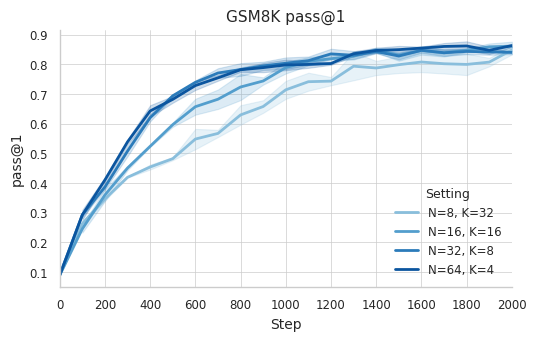

In [17]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(5.25, 3.3), constrained_layout=True)
plot_ready_df = pass_at_1_df.copy()
plot_ready_df["setting"] = pd.Categorical(
    plot_ready_df["group"].map(GROUP_LABELS),
    categories=[GROUP_LABELS[group] for group in GROUPS],
    ordered=True,
)
blue_palette = dict(zip(plot_ready_df["setting"].cat.categories, sns.color_palette("Blues", n_colors=len(GROUPS) + 2)[2:]))

lineplot_kwargs = dict(
    data=plot_ready_df,
    x="Step",
    y="value",
    hue="setting",
    hue_order=plot_ready_df["setting"].cat.categories,
    palette=blue_palette,
    estimator="mean",
    err_style="band",
    ax=ax,
)

if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
    sns.lineplot(**lineplot_kwargs, errorbar="se")
else:
    sns.lineplot(**lineplot_kwargs, ci="se")

ax.set_title("GSM8K pass@1")
ax.set_xlabel("Step")
ax.set_ylabel("pass@1")
ax.set_xlim(0, MAX_STEP)
ax.set_xticks(range(0, MAX_STEP + STEP_BIN, 200))
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Setting", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1.pdf", bbox_inches="tight")

## Plot difficulty metrics

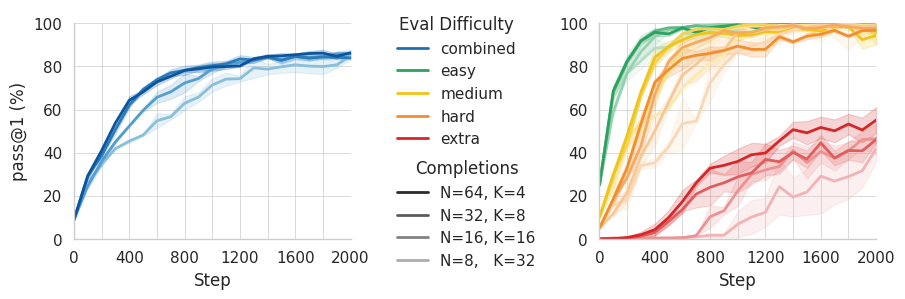

In [18]:
DIFFICULTY_METRICS = {
    "easy": "eval/gsm8k_pass25/pass_at_1",
    "medium": "eval/gsm8k_pass10/pass_at_1",
    "hard": "eval/gsm8k_pass5/pass_at_1",
    "extra": "eval/gsm8k_pass0/pass_at_1",
}
DIFFICULTY_INITIAL_VALUES = {
    "easy": 25,
    "medium": 10,
    "hard": 5,
    "extra": 0,
}
DIFFICULTY_BASE_COLORS = {
    "easy": "#2ca25f",
    "medium": "#f0c419",
    "hard": "#f28e2b",
    "extra": "#d62728",
}
COMBINED_COLOR = "#1f6fb4"


def blend_with_white(color: str, amount: float) -> tuple[float, float, float]:
    rgb = mpl.colors.to_rgb(color)
    return tuple((1 - amount) + amount * channel for channel in rgb)


difficulty_metrics_df = extract_metrics(raw_history_df[raw_history_df["run_id"] != INITIAL_RUN_ID], DIFFICULTY_METRICS)
difficulty_initial_df = pd.DataFrame(
    [
        {
            "group": group,
            "run_id": INITIAL_RUN_ID,
            "run_name": INITIAL_RUN_NAME,
            "metric": metric,
            "metric_key": DIFFICULTY_METRICS[metric],
            "Step": 0,
            "value": initial_value / 100,
            "raw_step": 0,
        }
        for group in GROUPS
        for metric, initial_value in DIFFICULTY_INITIAL_VALUES.items()
    ]
)
difficulty_plot_df = pd.concat([difficulty_initial_df, difficulty_metrics_df], ignore_index=True)
difficulty_plot_df["group"] = pd.Categorical(difficulty_plot_df["group"], categories=GROUPS, ordered=True)
difficulty_plot_df["setting"] = pd.Categorical(
    difficulty_plot_df["group"].map(GROUP_LABELS),
    categories=[GROUP_LABELS[group] for group in GROUPS],
    ordered=True,
)
difficulty_plot_df["metric"] = pd.Categorical(
    difficulty_plot_df["metric"],
    categories=list(DIFFICULTY_METRICS),
    ordered=True,
)
difficulty_plot_df["pass_at_1_percent"] = difficulty_plot_df["value"] * 100
difficulty_plot_df["series"] = difficulty_plot_df["metric"].astype(str) + " | " + difficulty_plot_df["setting"].astype(str)

shade_strengths = [0.35, 0.5, 0.75, 1.0]
difficulty_palette = {
    f"{metric} | {GROUP_LABELS[group]}": blend_with_white(DIFFICULTY_BASE_COLORS[metric], shade_strength)
    for metric in DIFFICULTY_METRICS
    for group, shade_strength in zip(GROUPS, shade_strengths)
}
series_order = [
    f"{metric} | {GROUP_LABELS[group]}"
    for metric in DIFFICULTY_METRICS
    for group in GROUPS
]

combined_rc = {
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
}
with mpl.rc_context(combined_rc):
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
    )

    left_plot_df = pass_at_1_df.copy()
    left_plot_df["setting"] = pd.Categorical(
        left_plot_df["group"].map(GROUP_LABELS),
        categories=[GROUP_LABELS[group] for group in GROUPS],
        ordered=True,
    )
    left_plot_df["pass_at_1_percent"] = left_plot_df["value"] * 100
    setting_order = list(left_plot_df["setting"].cat.categories)
    gray_palette = dict(
        zip(setting_order, sns.color_palette("Greys", n_colors=len(setting_order) + 2)[2:])
    )
    left_lineplot_kwargs = dict(
        data=left_plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="setting",
        hue_order=setting_order,
        palette=blue_palette,
        estimator="mean",
        err_style="band",
        ax=ax_left,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**left_lineplot_kwargs, errorbar="se")
    else:
        sns.lineplot(**left_lineplot_kwargs, ci="se")

    ax_left.set_xlabel("Step")
    ax_left.set_ylabel("pass@1 (%)")
    ax_left.set_xlim(0, MAX_STEP)
    ax_left.set_ylim(0, 100)
    ax_left.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_left.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_left.tick_params(axis="x", which="minor", length=0)
    ax_left.grid(which="minor", axis="x", linewidth=0.5)
    ax_left.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax_left)

    right_lineplot_kwargs = dict(
        data=difficulty_plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="series",
        hue_order=series_order,
        palette=difficulty_palette,
        estimator="mean",
        err_style="band",
        ax=ax_right,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**right_lineplot_kwargs, errorbar="se")
    else:
        sns.lineplot(**right_lineplot_kwargs, ci="se")

    ax_right.set_xlabel("Step")
    ax_right.set_ylabel("")
    ax_right.set_xlim(0, MAX_STEP)
    ax_right.set_ylim(0, 100)
    ax_right.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_right.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_right.tick_params(axis="x", which="minor", length=0)
    ax_right.grid(which="minor", axis="x", linewidth=0.5)
    ax_right.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax_right)

    ax_left.get_legend().remove()
    if ax_right.get_legend() is not None:
        ax_right.get_legend().remove()

    FIGURE_SPACE = "\u2007"

    def _align_setting(label: str) -> str:
        n_part, k_part = [piece.strip() for piece in label.split(",")]
        n_digits = n_part.split("=")[1]
        pad = FIGURE_SPACE * (2 - len(n_digits))
        return f"{n_part},{pad} {k_part}"

    setting_labels_aligned = [_align_setting(s) for s in setting_order]
    setting_handles = [
        mpl.lines.Line2D([0], [0], color=gray_palette[setting], lw=2.0) for setting in setting_order
    ]

    difficulty_legend_handles = [mpl.lines.Line2D([0], [0], color=COMBINED_COLOR, lw=2.0)] + [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS[metric], lw=2.0)
        for metric in DIFFICULTY_METRICS
    ]
    difficulty_legend_labels = ["combined"] + list(DIFFICULTY_METRICS)
    difficulty_legend = ax_left.legend(
        difficulty_legend_handles,
        difficulty_legend_labels,
        title="Eval Difficulty",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.1),
    )
    ax_left.add_artist(difficulty_legend)

    ax_left.legend(
        list(reversed(setting_handles)),
        list(reversed(setting_labels_aligned)),
        title="Completions",
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(1.12, -0.2),
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1_combined.pdf", bbox_inches="tight")

## Plot nonzero-prompt ratios

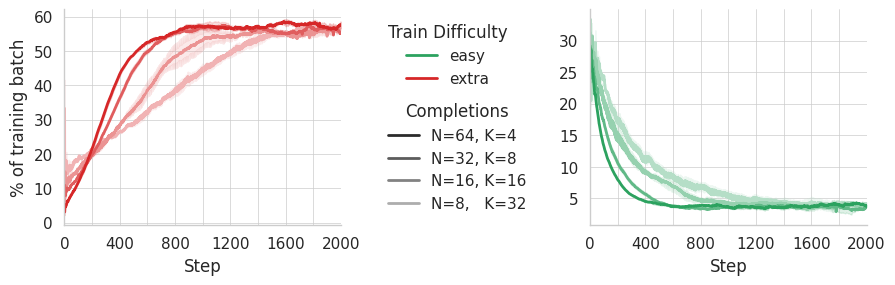

In [19]:
NONZERO_Q3_COL = "batch/nonzero_prompts/gsm8k_quartile3"
NONZERO_Q0_COL = "batch/nonzero_prompts/gsm8k_quartile0"
TOTAL_PROMPTS_COL = "batch/total_prompts"
SUBSAMPLE_STEP = 1
EMA_DECAY = 0.995

train_history_df = raw_history_df[raw_history_df["run_id"] != INITIAL_RUN_ID].copy()
needed_cols = [NONZERO_Q3_COL, NONZERO_Q0_COL, TOTAL_PROMPTS_COL]
missing = [c for c in needed_cols if c not in train_history_df.columns]
if missing:
    raise ValueError(f"Missing required train metric columns: {missing}")

base_cols = ["group", "run_id", "run_name", "raw_step"]
ratio_df = train_history_df[base_cols + needed_cols].dropna(subset=needed_cols).copy()
ratio_df["q3_ratio"] = ratio_df[NONZERO_Q3_COL] / ratio_df[TOTAL_PROMPTS_COL] * 100
ratio_df["q0_ratio"] = ratio_df[NONZERO_Q0_COL] / ratio_df[TOTAL_PROMPTS_COL] * 100
ratio_df["Step"] = ratio_df["raw_step"].astype(int)
ratio_df = ratio_df[(ratio_df["Step"] >= 0) & (ratio_df["Step"] <= MAX_STEP)]

ratio_df["step_bin"] = (ratio_df["Step"] // SUBSAMPLE_STEP) * SUBSAMPLE_STEP
ratio_df = (
    ratio_df.sort_values(["group", "run_id", "Step"])
    .groupby(["group", "run_id", "run_name", "step_bin"], as_index=False)
    .agg(q3_ratio=("q3_ratio", "last"), q0_ratio=("q0_ratio", "last"), Step=("Step", "last"))
)
ratio_df["Step"] = ratio_df["step_bin"]
ratio_df = ratio_df.sort_values(["group", "run_id", "Step"]).reset_index(drop=True)
for col in ("q3_ratio", "q0_ratio"):
    ratio_df[col] = (
        ratio_df.groupby(["group", "run_id"], observed=True)[col]
        .transform(lambda s: s.ewm(alpha=1 - EMA_DECAY, adjust=True).mean())
    )
ratio_df["setting"] = pd.Categorical(
    ratio_df["group"].map(GROUP_LABELS),
    categories=[GROUP_LABELS[g] for g in GROUPS],
    ordered=True,
)

with mpl.rc_context(combined_rc):
    fig, (ax_q3, ax_q0) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
    )

    hard_palette = {
        setting: blend_with_white(DIFFICULTY_BASE_COLORS["extra"], shade)
        for setting, shade in zip(setting_order, shade_strengths)
    }
    easy_palette = {
        setting: blend_with_white(DIFFICULTY_BASE_COLORS["easy"], shade)
        for setting, shade in zip(setting_order, shade_strengths)
    }

    for ax, ycol, title, palette in [
        (ax_q3, "q3_ratio", "Extra Hard Prompts", hard_palette),
        (ax_q0, "q0_ratio", "Easy Prompts", easy_palette),
    ]:
        ylabel = "% of training batch"
        kwargs = dict(
            data=ratio_df,
            x="Step",
            y=ycol,
            hue="setting",
            hue_order=setting_order,
            palette=palette,
            estimator="mean",
            err_style="band",
            ax=ax,
        )
        if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
            sns.lineplot(**kwargs, errorbar="se")
        else:
            sns.lineplot(**kwargs, ci="sd")
        ax.set_xlabel("Step")
        ax.set_ylabel(ylabel if ax is ax_q3 else "")
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 400))
        ax.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
        ax.tick_params(axis="x", which="minor", length=0)
        ax.grid(which="minor", axis="x", linewidth=0.5)
        sns.despine(ax=ax)

    ax_q3.get_legend().remove()
    if ax_q0.get_legend() is not None:
        ax_q0.get_legend().remove()

    ratio_gray_palette = dict(
        zip(setting_order, sns.color_palette("Greys", n_colors=len(setting_order) + 2)[2:])
    )
    ratio_setting_handles = [
        mpl.lines.Line2D([0], [0], color=ratio_gray_palette[s], lw=2.0) for s in setting_order
    ]

    ratio_difficulty_handles = [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["easy"], lw=2.0),
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["extra"], lw=2.0),
    ]
    ratio_difficulty_labels = ["easy", "extra"]
    ratio_difficulty_legend = ax_q3.legend(
        ratio_difficulty_handles,
        ratio_difficulty_labels,
        title="Train Difficulty",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.0),
    )
    ax_q3.add_artist(ratio_difficulty_legend)

    ax_q3.legend(
        list(reversed(ratio_setting_handles)),
        list(reversed(setting_labels_aligned)),
        title="Completions",
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(1.12, 0.0),
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_nonzero_prompt_ratios.pdf", bbox_inches="tight")

## Plots including ngu_n64_k4_grad25_age4

In [20]:
NGU_GROUP = "ngu_n64_k4_grad25_age4"
NGU_LABEL = "NGU N=64 K=4"
NGU_COLOR = "#7b3294"

ngu_runs = list(api.runs(PROJECT_PATH, filters={"group": NGU_GROUP}))
print(f"{NGU_GROUP}: found {len(ngu_runs)} runs")
ngu_run_by_id: dict[str, wandb.apis.public.Run] = {}
ngu_rows = []
for run in ngu_runs:
    ngu_run_by_id[run.id] = run
    ngu_rows.append(
        {
            "group": NGU_GROUP,
            "run_id": run.id,
            "run_name": run.name,
            "state": run.state,
            "created_at": run.created_at,
            "url": run.url,
        }
    )
ngu_runs_df = pd.DataFrame(ngu_rows).sort_values(["created_at", "run_id"]).reset_index(drop=True)

ngu_histories = []
for run_row in ngu_runs_df.itertuples(index=False):
    run = ngu_run_by_id[run_row.run_id]
    history = download_run_history(run, group=NGU_GROUP, run_name=run_row.run_name)
    print(f"{run.id}: downloaded {len(history):,} history rows")
    if not history.empty:
        ngu_histories.append(history)
ngu_history_df = pd.concat(ngu_histories, ignore_index=True, sort=False)

EXTENDED_GROUPS = list(GROUPS) + [NGU_GROUP]
EXTENDED_GROUP_LABELS = {**GROUP_LABELS, NGU_GROUP: NGU_LABEL}
extended_setting_order = [EXTENDED_GROUP_LABELS[g] for g in EXTENDED_GROUPS]
GREY_SHADES = ["#d9d9d9", "#bdbdbd", "#969696", "#636363"]
extended_blue_palette = {
    **{EXTENDED_GROUP_LABELS[g]: GREY_SHADES[i] for i, g in enumerate(GROUPS)},
    NGU_LABEL: NGU_COLOR,
}

extended_history_df = pd.concat([raw_history_df, ngu_history_df], ignore_index=True, sort=False)


def _align_setting_extended(label: str) -> str:
    if "," not in label:
        return label
    n_part, k_part = [piece.strip() for piece in label.split(",")]
    n_digits = n_part.split("=")[-1]
    pad = "\u2007" * (2 - len(n_digits))
    return f"{n_part},{pad} {k_part}"


extended_setting_labels_aligned = [_align_setting_extended(s) for s in extended_setting_order]

ngu_n64_k4_grad25_age4: found 3 runs
z2ootlxo: downloaded 1,999 history rows
mfuilyhe: downloaded 1,997 history rows
goj9yk1p: downloaded 1,999 history rows


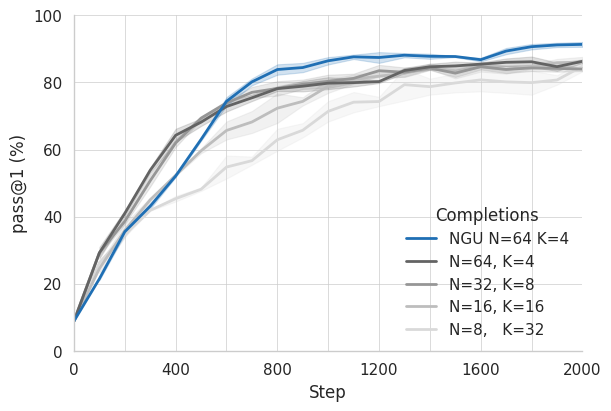

In [21]:
ext_metrics_df = extract_metrics(extended_history_df[extended_history_df["run_id"] != INITIAL_RUN_ID], METRICS)
ext_initial_df = extract_initial_eval(extended_history_df, EXTENDED_GROUPS, METRICS)
ext_plot_df = pd.concat([ext_initial_df, ext_metrics_df], ignore_index=True)
ext_plot_df["group"] = pd.Categorical(ext_plot_df["group"], categories=EXTENDED_GROUPS, ordered=True)
ext_plot_df = ext_plot_df.sort_values(["group", "run_id", "metric", "Step"]).reset_index(drop=True)
ext_pass_at_1_df = ext_plot_df[ext_plot_df["metric"] == PLOT_METRIC_NAME].copy()
ext_pass_at_1_df["setting"] = pd.Categorical(
    ext_pass_at_1_df["group"].map(EXTENDED_GROUP_LABELS),
    categories=extended_setting_order,
    ordered=True,
)
ext_pass_at_1_df["pass_at_1_percent"] = ext_pass_at_1_df["value"] * 100

ext_pass_at_1_palette = {
    **{EXTENDED_GROUP_LABELS[g]: GREY_SHADES[i] for i, g in enumerate(GROUPS)},
    NGU_LABEL: COMBINED_COLOR,
}


def _strip_ngu(label: str) -> str:
    if not label.startswith("NGU "):
        return label
    rest = label[4:]
    if "," in rest:
        rest = rest.split(",", 1)[1].strip()
    return f"NGU {rest}"


ext_setting_labels_clean = [_strip_ngu(s) for s in extended_setting_labels_aligned]

with mpl.rc_context(combined_rc):
    fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)
    kwargs = dict(
        data=ext_pass_at_1_df,
        x="Step",
        y="pass_at_1_percent",
        hue="setting",
        hue_order=extended_setting_order,
        palette=ext_pass_at_1_palette,
        estimator="mean",
        err_style="band",
        ax=ax,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**kwargs, errorbar="se")
    else:
        sns.lineplot(**kwargs, ci="sd")
    ax.set_xlabel("Step")
    ax.set_ylabel("pass@1 (%)")
    ax.set_xlim(0, MAX_STEP)
    ax.set_ylim(0, 100)
    ax.set_xticks(range(0, MAX_STEP + 1, 400))
    ax.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax.tick_params(axis="x", which="minor", length=0)
    ax.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax)
    ax.get_legend().remove()
    handles = [mpl.lines.Line2D([0], [0], color=ext_pass_at_1_palette[s], lw=2.0) for s in extended_setting_order]
    ax.legend(
        list(reversed(handles)),
        list(reversed(ext_setting_labels_clean)),
        title="Completions",
        frameon=False,
        loc="best",
    )
    fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1_with_ngu.pdf", bbox_inches="tight")

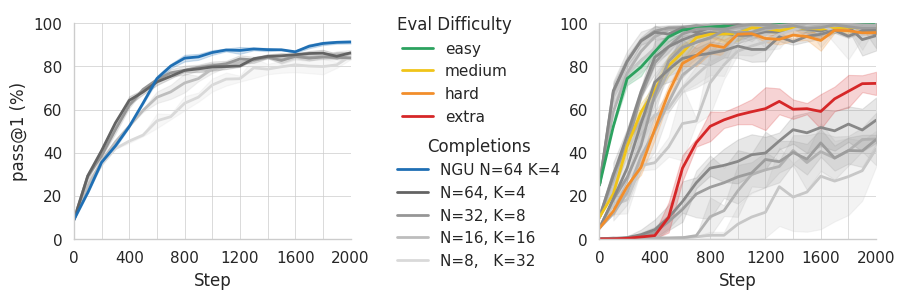

In [22]:
ext_difficulty_metrics_df = extract_metrics(
    extended_history_df[extended_history_df["run_id"] != INITIAL_RUN_ID], DIFFICULTY_METRICS
)
ext_difficulty_initial_df = pd.DataFrame(
    [
        {
            "group": group,
            "run_id": INITIAL_RUN_ID,
            "run_name": INITIAL_RUN_NAME,
            "metric": metric,
            "metric_key": DIFFICULTY_METRICS[metric],
            "Step": 0,
            "value": initial_value / 100,
            "raw_step": 0,
        }
        for group in EXTENDED_GROUPS
        for metric, initial_value in DIFFICULTY_INITIAL_VALUES.items()
    ]
)
ext_difficulty_plot_df = pd.concat([ext_difficulty_initial_df, ext_difficulty_metrics_df], ignore_index=True)
ext_difficulty_plot_df["group"] = pd.Categorical(ext_difficulty_plot_df["group"], categories=EXTENDED_GROUPS, ordered=True)
ext_difficulty_plot_df["setting"] = pd.Categorical(
    ext_difficulty_plot_df["group"].map(EXTENDED_GROUP_LABELS),
    categories=extended_setting_order,
    ordered=True,
)
ext_difficulty_plot_df["metric"] = pd.Categorical(
    ext_difficulty_plot_df["metric"], categories=list(DIFFICULTY_METRICS), ordered=True
)
ext_difficulty_plot_df["pass_at_1_percent"] = ext_difficulty_plot_df["value"] * 100
ext_difficulty_plot_df["series"] = (
    ext_difficulty_plot_df["metric"].astype(str) + " | " + ext_difficulty_plot_df["setting"].astype(str)
)

ext_shade_strengths = [0.4, 0.55, 0.7, 0.85, 1.0]
GREY_BASE = "#737373"
ext_difficulty_palette = {
    f"{metric} | {EXTENDED_GROUP_LABELS[group]}": (
        DIFFICULTY_BASE_COLORS[metric] if group == NGU_GROUP else blend_with_white(GREY_BASE, shade)
    )
    for metric in DIFFICULTY_METRICS
    for group, shade in zip(EXTENDED_GROUPS, ext_shade_strengths)
}
ext_series_order = [
    f"{metric} | {EXTENDED_GROUP_LABELS[group]}"
    for metric in DIFFICULTY_METRICS
    for group in EXTENDED_GROUPS
]

with mpl.rc_context(combined_rc):
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
    )

    ext_left_df = ext_pass_at_1_df.copy()
    left_kwargs = dict(
        data=ext_left_df,
        x="Step",
        y="pass_at_1_percent",
        hue="setting",
        hue_order=extended_setting_order,
        palette=ext_pass_at_1_palette,
        estimator="mean",
        err_style="band",
        ax=ax_left,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**left_kwargs, errorbar="se")
    else:
        sns.lineplot(**left_kwargs, ci="sd")
    ax_left.set_xlabel("Step")
    ax_left.set_ylabel("pass@1 (%)")
    ax_left.set_xlim(0, MAX_STEP)
    ax_left.set_ylim(0, 100)
    ax_left.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_left.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_left.tick_params(axis="x", which="minor", length=0)
    ax_left.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_left)

    right_kwargs = dict(
        data=ext_difficulty_plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="series",
        hue_order=ext_series_order,
        palette=ext_difficulty_palette,
        estimator="mean",
        err_style="band",
        ax=ax_right,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**right_kwargs, errorbar="sd")
    else:
        sns.lineplot(**right_kwargs, ci="sd")
    ax_right.set_xlabel("Step")
    ax_right.set_ylabel("")
    ax_right.set_xlim(0, MAX_STEP)
    ax_right.set_ylim(0, 100)
    ax_right.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_right.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_right.tick_params(axis="x", which="minor", length=0)
    ax_right.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_right)

    ax_left.get_legend().remove()
    if ax_right.get_legend() is not None:
        ax_right.get_legend().remove()

    diff_handles = [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS[metric], lw=2.0) for metric in DIFFICULTY_METRICS
    ]
    diff_labels = list(DIFFICULTY_METRICS)
    diff_legend = ax_left.legend(
        diff_handles,
        diff_labels,
        title="Eval Difficulty",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.1),
    )
    ax_left.add_artist(diff_legend)

    ext_setting_handles = [
        mpl.lines.Line2D([0], [0], color=ext_pass_at_1_palette[s], lw=2.0) for s in extended_setting_order
    ]
    ax_left.legend(
        list(reversed(ext_setting_handles)),
        list(reversed(ext_setting_labels_clean)),
        title="Completions",
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(1.12, -0.2),
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1_combined_with_ngu.pdf", bbox_inches="tight")

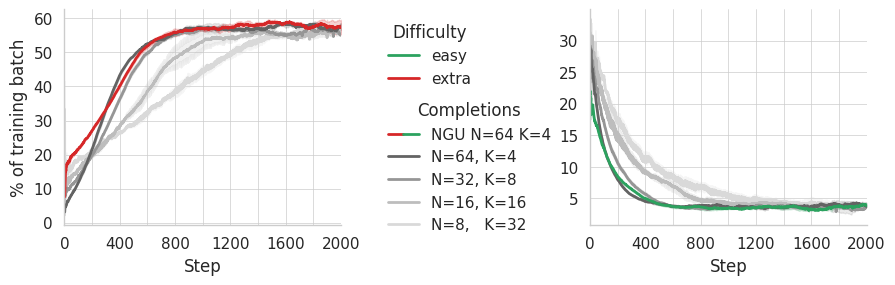

In [23]:
ext_train_history_df = extended_history_df[extended_history_df["run_id"] != INITIAL_RUN_ID].copy()
ext_missing = [c for c in needed_cols if c not in ext_train_history_df.columns]
if ext_missing:
    raise ValueError(f"Missing required train metric columns: {ext_missing}")

ext_ratio_df = ext_train_history_df[base_cols + needed_cols].dropna(subset=needed_cols).copy()
ext_ratio_df["q3_ratio"] = ext_ratio_df[NONZERO_Q3_COL] / ext_ratio_df[TOTAL_PROMPTS_COL] * 100
ext_ratio_df["q0_ratio"] = ext_ratio_df[NONZERO_Q0_COL] / ext_ratio_df[TOTAL_PROMPTS_COL] * 100
ext_ratio_df["Step"] = ext_ratio_df["raw_step"].astype(int)
ext_ratio_df = ext_ratio_df[(ext_ratio_df["Step"] >= 0) & (ext_ratio_df["Step"] <= MAX_STEP)]
ext_ratio_df["step_bin"] = (ext_ratio_df["Step"] // SUBSAMPLE_STEP) * SUBSAMPLE_STEP
ext_ratio_df = (
    ext_ratio_df.sort_values(["group", "run_id", "Step"])
    .groupby(["group", "run_id", "run_name", "step_bin"], as_index=False)
    .agg(q3_ratio=("q3_ratio", "last"), q0_ratio=("q0_ratio", "last"), Step=("Step", "last"))
)
ext_ratio_df["Step"] = ext_ratio_df["step_bin"]
ext_ratio_df = ext_ratio_df.sort_values(["group", "run_id", "Step"]).reset_index(drop=True)
for col in ("q3_ratio", "q0_ratio"):
    ext_ratio_df[col] = (
        ext_ratio_df.groupby(["group", "run_id"], observed=True)[col]
        .transform(lambda s: s.ewm(alpha=1 - EMA_DECAY, adjust=True).mean())
    )
ext_ratio_df["setting"] = pd.Categorical(
    ext_ratio_df["group"].map(EXTENDED_GROUP_LABELS),
    categories=extended_setting_order,
    ordered=True,
)

with mpl.rc_context(combined_rc):
    fig, (ax_q3, ax_q0) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
    )

    ext_ratio_gray_palette = {
        EXTENDED_GROUP_LABELS[g]: GREY_SHADES[i] for i, g in enumerate(GROUPS)
    }
    ext_hard_palette = {
        **ext_ratio_gray_palette,
        NGU_LABEL: DIFFICULTY_BASE_COLORS["extra"],
    }
    ext_easy_palette = {
        **ext_ratio_gray_palette,
        NGU_LABEL: DIFFICULTY_BASE_COLORS["easy"],
    }

    for ax, ycol, palette in [
        (ax_q3, "q3_ratio", ext_hard_palette),
        (ax_q0, "q0_ratio", ext_easy_palette),
    ]:
        kwargs = dict(
            data=ext_ratio_df,
            x="Step",
            y=ycol,
            hue="setting",
            hue_order=extended_setting_order,
            palette=palette,
            estimator="mean",
            err_style="band",
            ax=ax,
        )
        if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
            sns.lineplot(**kwargs, errorbar="se")
        else:
            sns.lineplot(**kwargs, ci="sd")
        ax.set_xlabel("Step")
        ax.set_ylabel("% of training batch" if ax is ax_q3 else "")
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 400))
        ax.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
        ax.tick_params(axis="x", which="minor", length=0)
        ax.grid(which="minor", axis="x", linewidth=0.5)
        sns.despine(ax=ax)

    ax_q3.get_legend().remove()
    if ax_q0.get_legend() is not None:
        ax_q0.get_legend().remove()

    ext_ratio_difficulty_handles = [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["easy"], lw=2.0),
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["extra"], lw=2.0),
    ]
    ext_ratio_difficulty_legend = ax_q3.legend(
        ext_ratio_difficulty_handles,
        ["easy", "extra"],
        title="Difficulty",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.0),
    )
    ax_q3.add_artist(ext_ratio_difficulty_legend)

    from matplotlib.legend_handler import HandlerTuple

    ext_ratio_setting_handles = [
        (
            mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["extra"], lw=2.0),
            mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS["easy"], lw=2.0),
        )
        if s == NGU_LABEL
        else mpl.lines.Line2D([0], [0], color=ext_ratio_gray_palette[s], lw=2.0)
        for s in extended_setting_order
    ]
    ax_q3.legend(
        list(reversed(ext_ratio_setting_handles)),
        list(reversed(ext_setting_labels_clean)),
        title="Completions",
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(1.12, -0.1),
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.0)},
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_nonzero_prompt_ratios_with_ngu.pdf", bbox_inches="tight")

## Plots across NGU Max Age (T)

In [24]:
AGE_GROUPS = [
    "ngu_comp_age_false",
    "ngu_comp_age_4",
    "ngu_comp_age_8",
    "ngu_comp_age_16",
]
AGE_GROUP_LABELS = {
    "ngu_comp_age_false": "T=1",
    "ngu_comp_age_4": "T=4",
    "ngu_comp_age_8": "T=8",
    "ngu_comp_age_16": "T=16",
}

age_runs_df, age_run_by_id = collect_group_runs(AGE_GROUPS)
age_raw_history_df = download_run_histories(age_runs_df, age_run_by_id)

age_metrics_df = extract_metrics(age_raw_history_df[age_raw_history_df["run_id"] != INITIAL_RUN_ID], METRICS)
age_initial_df = extract_initial_eval(age_raw_history_df, AGE_GROUPS, METRICS)
age_plot_df = pd.concat([age_initial_df, age_metrics_df], ignore_index=True)
age_plot_df["group"] = pd.Categorical(age_plot_df["group"], categories=AGE_GROUPS, ordered=True)
age_plot_df = age_plot_df.sort_values(["group", "run_id", "metric", "Step"]).reset_index(drop=True)
age_pass_at_1_df = age_plot_df[age_plot_df["metric"] == PLOT_METRIC_NAME].copy()

age_difficulty_metrics_df = extract_metrics(
    age_raw_history_df[age_raw_history_df["run_id"] != INITIAL_RUN_ID], DIFFICULTY_METRICS
)
age_difficulty_initial_df = pd.DataFrame(
    [
        {
            "group": group,
            "run_id": INITIAL_RUN_ID,
            "run_name": INITIAL_RUN_NAME,
            "metric": metric,
            "metric_key": DIFFICULTY_METRICS[metric],
            "Step": 0,
            "value": initial_value / 100,
            "raw_step": 0,
        }
        for group in AGE_GROUPS
        for metric, initial_value in DIFFICULTY_INITIAL_VALUES.items()
    ]
)
age_difficulty_plot_df = pd.concat([age_difficulty_initial_df, age_difficulty_metrics_df], ignore_index=True)
age_difficulty_plot_df["group"] = pd.Categorical(age_difficulty_plot_df["group"], categories=AGE_GROUPS, ordered=True)
age_difficulty_plot_df["setting"] = pd.Categorical(
    age_difficulty_plot_df["group"].map(AGE_GROUP_LABELS),
    categories=[AGE_GROUP_LABELS[g] for g in AGE_GROUPS],
    ordered=True,
)
age_difficulty_plot_df["metric"] = pd.Categorical(
    age_difficulty_plot_df["metric"], categories=list(DIFFICULTY_METRICS), ordered=True
)
age_difficulty_plot_df["pass_at_1_percent"] = age_difficulty_plot_df["value"] * 100
age_difficulty_plot_df["series"] = (
    age_difficulty_plot_df["metric"].astype(str) + " | " + age_difficulty_plot_df["setting"].astype(str)
)

age_difficulty_palette = {
    f"{metric} | {AGE_GROUP_LABELS[group]}": blend_with_white(DIFFICULTY_BASE_COLORS[metric], shade_strength)
    for metric in DIFFICULTY_METRICS
    for group, shade_strength in zip(AGE_GROUPS, list(reversed(shade_strengths)))
}
age_series_order = [
    f"{metric} | {AGE_GROUP_LABELS[group]}"
    for metric in DIFFICULTY_METRICS
    for group in AGE_GROUPS
]

ngu_comp_age_false: found 3 runs
ngu_comp_age_4: found 3 runs
ngu_comp_age_8: found 3 runs
ngu_comp_age_16: found 3 runs
t1uug20z: downloaded 2,000 history rows
7otu8x4m: downloaded 2,000 history rows
c5p798iz: downloaded 2,000 history rows
zutk72ai: downloaded 2,000 history rows
qqgs49tj: downloaded 2,000 history rows
p0kc74km: downloaded 2,000 history rows
i6la4n3m: downloaded 2,000 history rows
67prnw74: downloaded 2,000 history rows
rct7wzxj: downloaded 2,000 history rows
ozh25d7s: downloaded 2,000 history rows
oud2q17i: downloaded 2,000 history rows
n0fxeqm7: downloaded 2,000 history rows
qtenf0on: downloaded 1 initial eval history rows


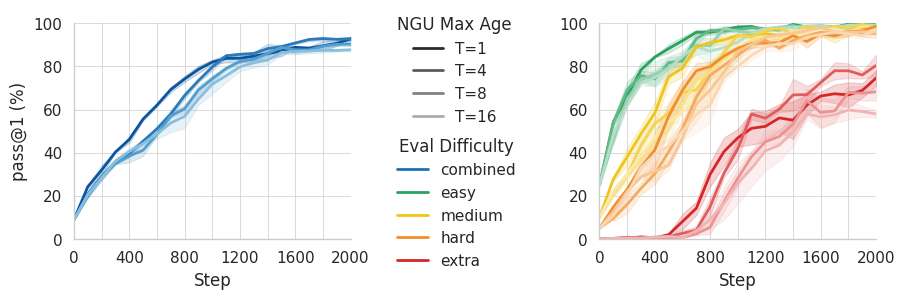

In [25]:
with mpl.rc_context(combined_rc):
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
    )

    age_left_df = age_pass_at_1_df.copy()
    age_left_df["setting"] = pd.Categorical(
        age_left_df["group"].map(AGE_GROUP_LABELS),
        categories=[AGE_GROUP_LABELS[g] for g in AGE_GROUPS],
        ordered=True,
    )
    age_left_df["pass_at_1_percent"] = age_left_df["value"] * 100
    age_setting_order = list(age_left_df["setting"].cat.categories)
    age_blue_palette = dict(
        zip(age_setting_order, list(reversed(sns.color_palette("Blues", n_colors=len(age_setting_order) + 2)[2:])))
    )
    age_gray_palette = dict(
        zip(age_setting_order, list(reversed(sns.color_palette("Greys", n_colors=len(age_setting_order) + 2)[2:])))
    )

    left_kwargs = dict(
        data=age_left_df,
        x="Step",
        y="pass_at_1_percent",
        hue="setting",
        hue_order=age_setting_order,
        palette=age_blue_palette,
        estimator="mean",
        err_style="band",
        ax=ax_left,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**left_kwargs, errorbar="se")
    else:
        sns.lineplot(**left_kwargs, ci="se")

    ax_left.set_xlabel("Step")
    ax_left.set_ylabel("pass@1 (%)")
    ax_left.set_xlim(0, MAX_STEP)
    ax_left.set_ylim(0, 100)
    ax_left.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_left.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_left.tick_params(axis="x", which="minor", length=0)
    ax_left.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_left)

    right_kwargs = dict(
        data=age_difficulty_plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="series",
        hue_order=age_series_order,
        palette=age_difficulty_palette,
        estimator="mean",
        err_style="band",
        ax=ax_right,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**right_kwargs, errorbar="se")
    else:
        sns.lineplot(**right_kwargs, ci="se")

    ax_right.set_xlabel("Step")
    ax_right.set_ylabel("")
    ax_right.set_xlim(0, MAX_STEP)
    ax_right.set_ylim(0, 100)
    ax_right.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_right.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_right.tick_params(axis="x", which="minor", length=0)
    ax_right.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_right)

    ax_left.get_legend().remove()
    if ax_right.get_legend() is not None:
        ax_right.get_legend().remove()

    age_setting_handles = [
        mpl.lines.Line2D([0], [0], color=age_gray_palette[s], lw=2.0) for s in age_setting_order
    ]

    age_difficulty_legend_handles = [mpl.lines.Line2D([0], [0], color=COMBINED_COLOR, lw=2.0)] + [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS[metric], lw=2.0)
        for metric in DIFFICULTY_METRICS
    ]
    age_difficulty_legend_labels = ["combined"] + list(DIFFICULTY_METRICS)
    age_setting_legend = ax_left.legend(
        age_setting_handles,
        age_setting_order,
        title="NGU Max Age",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.12, 1.1),
    )
    ax_left.add_artist(age_setting_legend)

    ax_left.legend(
        age_difficulty_legend_handles,
        age_difficulty_legend_labels,
        title="Eval Difficulty",
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(1.12, -0.2),
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1_combined_ngu_max_age.pdf", bbox_inches="tight")

## Plots across NGU Baseline

ngu_comp4_count_norescale: found 3 runs
ngu_comp4_count_downsample: found 3 runs
ngu_comp4_count_anchorpos: found 3 runs
iz0fccqd: downloaded 2,000 history rows
p444z532: downloaded 2,000 history rows
pfmttn3d: downloaded 2,000 history rows
61qo2t05: downloaded 2,000 history rows
x4l10rk2: downloaded 2,000 history rows
0isqjeap: downloaded 2,000 history rows
6swm56wt: downloaded 2,000 history rows
zzmi3miw: downloaded 2,000 history rows
f5ou8t8c: downloaded 2,000 history rows
qtenf0on: downloaded 1 initial eval history rows


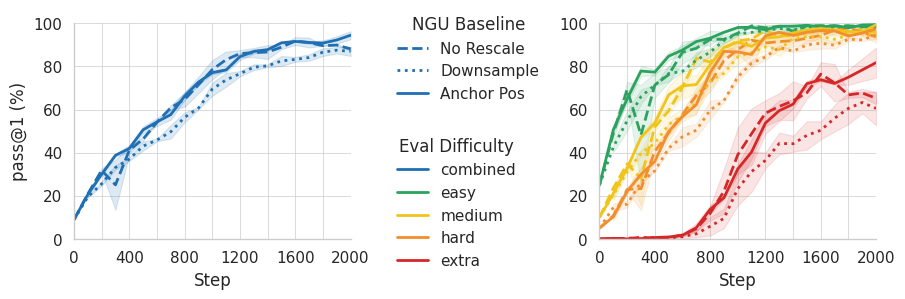

In [26]:
BASELINE_GROUPS = [
    "ngu_comp4_count_norescale",
    "ngu_comp4_count_downsample",
    "ngu_comp4_count_anchorpos",
]
BASELINE_GROUP_LABELS = {
    "ngu_comp4_count_norescale": "No Rescale",
    "ngu_comp4_count_downsample": "Downsample",
    "ngu_comp4_count_anchorpos": "Anchor Pos",
}
BASELINE_LINESTYLES = {
    "No Rescale": "--",
    "Downsample": ":",
    "Anchor Pos": "-",
}
BASELINE_DRAW_ORDER = ["No Rescale", "Downsample", "Anchor Pos"]
BASELINE_LEGEND_ORDER = ["No Rescale", "Downsample", "Anchor Pos"]
BASELINE_COLOR = "#1f6fb4"

baseline_runs_df, baseline_run_by_id = collect_group_runs(BASELINE_GROUPS)
baseline_raw_history_df = download_run_histories(baseline_runs_df, baseline_run_by_id)

baseline_metrics_df = extract_metrics(
    baseline_raw_history_df[baseline_raw_history_df["run_id"] != INITIAL_RUN_ID], METRICS
)
baseline_initial_df = extract_initial_eval(baseline_raw_history_df, BASELINE_GROUPS, METRICS)
baseline_plot_df = pd.concat([baseline_initial_df, baseline_metrics_df], ignore_index=True)
baseline_plot_df["group"] = pd.Categorical(baseline_plot_df["group"], categories=BASELINE_GROUPS, ordered=True)
baseline_plot_df = baseline_plot_df.sort_values(["group", "run_id", "metric", "Step"]).reset_index(drop=True)
baseline_pass_at_1_df = baseline_plot_df[baseline_plot_df["metric"] == PLOT_METRIC_NAME].copy()

baseline_difficulty_metrics_df = extract_metrics(
    baseline_raw_history_df[baseline_raw_history_df["run_id"] != INITIAL_RUN_ID], DIFFICULTY_METRICS
)
baseline_difficulty_initial_df = pd.DataFrame(
    [
        {
            "group": group,
            "run_id": INITIAL_RUN_ID,
            "run_name": INITIAL_RUN_NAME,
            "metric": metric,
            "metric_key": DIFFICULTY_METRICS[metric],
            "Step": 0,
            "value": initial_value / 100,
            "raw_step": 0,
        }
        for group in BASELINE_GROUPS
        for metric, initial_value in DIFFICULTY_INITIAL_VALUES.items()
    ]
)
baseline_difficulty_plot_df = pd.concat(
    [baseline_difficulty_initial_df, baseline_difficulty_metrics_df], ignore_index=True
)
baseline_difficulty_plot_df["group"] = pd.Categorical(
    baseline_difficulty_plot_df["group"], categories=BASELINE_GROUPS, ordered=True
)
baseline_difficulty_plot_df["setting"] = pd.Categorical(
    baseline_difficulty_plot_df["group"].map(BASELINE_GROUP_LABELS),
    categories=[BASELINE_GROUP_LABELS[g] for g in BASELINE_GROUPS],
    ordered=True,
)
baseline_difficulty_plot_df["metric"] = pd.Categorical(
    baseline_difficulty_plot_df["metric"], categories=list(DIFFICULTY_METRICS), ordered=True
)
baseline_difficulty_plot_df["pass_at_1_percent"] = baseline_difficulty_plot_df["value"] * 100


def _plot_linestyle_combined(
    pass_df,
    diff_df,
    settings_draw_order,
    settings_legend_order,
    linestyles,
    base_color,
    legend_title,
    output_pdf,
    completions_label_func=lambda s: s,
):
    """Combined pass@1 plot where each setting is a different linestyle (single color)."""
    pass_local = pass_df.copy()
    if "setting" not in pass_local.columns:
        all_labels = {**BASELINE_GROUP_LABELS}
        pass_local["setting"] = pass_local["group"].map(lambda g: all_labels.get(g, g))
    pass_local["pass_at_1_percent"] = pass_local["value"] * 100

    with mpl.rc_context(combined_rc):
        fig, (ax_left, ax_right) = plt.subplots(
            1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.9}, constrained_layout=False
        )

        for setting in settings_draw_order:
            subset = pass_local[pass_local["setting"] == setting]
            if subset.empty:
                continue
            agg = subset.groupby("Step")["pass_at_1_percent"].agg(mean="mean", sem="sem").reset_index()
            ax_left.plot(
                agg["Step"], agg["mean"], color=base_color, linestyle=linestyles[setting], linewidth=2.0
            )
            ax_left.fill_between(
                agg["Step"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"], color=base_color, alpha=0.15
            )

        ax_left.set_xlabel("Step")
        ax_left.set_ylabel("pass@1 (%)")
        ax_left.set_xlim(0, MAX_STEP)
        ax_left.set_ylim(0, 100)
        ax_left.set_xticks(range(0, MAX_STEP + 1, 400))
        ax_left.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
        ax_left.tick_params(axis="x", which="minor", length=0)
        ax_left.grid(which="minor", axis="x", linewidth=0.5)
        sns.despine(ax=ax_left)

        for setting in settings_draw_order:
            for metric in DIFFICULTY_METRICS:
                subset = diff_df[(diff_df["setting"] == setting) & (diff_df["metric"] == metric)]
                if subset.empty:
                    continue
                agg = subset.groupby("Step")["pass_at_1_percent"].agg(mean="mean", sem="sem").reset_index()
                color = DIFFICULTY_BASE_COLORS[metric]
                ax_right.plot(
                    agg["Step"], agg["mean"], color=color, linestyle=linestyles[setting], linewidth=2.0
                )
                ax_right.fill_between(
                    agg["Step"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"], color=color, alpha=0.12
                )

        ax_right.set_xlabel("Step")
        ax_right.set_ylabel("")
        ax_right.set_xlim(0, MAX_STEP)
        ax_right.set_ylim(0, 100)
        ax_right.set_xticks(range(0, MAX_STEP + 1, 400))
        ax_right.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
        ax_right.tick_params(axis="x", which="minor", length=0)
        ax_right.grid(which="minor", axis="x", linewidth=0.5)
        sns.despine(ax=ax_right)

        setting_handles = [
            mpl.lines.Line2D([0], [0], color=base_color, linestyle=linestyles[s], lw=2.0)
            for s in settings_legend_order
        ]
        setting_labels = [completions_label_func(s) for s in settings_legend_order]
        setting_legend = ax_left.legend(
            setting_handles,
            setting_labels,
            title=legend_title,
            frameon=False,
            loc="upper left",
            bbox_to_anchor=(1.12, 1.1),
        )
        ax_left.add_artist(setting_legend)

        diff_handles = [mpl.lines.Line2D([0], [0], color=COMBINED_COLOR, lw=2.0)] + [
            mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS[metric], lw=2.0)
            for metric in DIFFICULTY_METRICS
        ]
        diff_labels = ["combined"] + list(DIFFICULTY_METRICS)
        ax_left.legend(
            diff_handles,
            diff_labels,
            title="Eval Difficulty",
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(1.12, -0.2),
        )

        fig.savefig(OUTPUT_DIR / output_pdf, bbox_inches="tight")


_plot_linestyle_combined(
    baseline_pass_at_1_df,
    baseline_difficulty_plot_df,
    settings_draw_order=BASELINE_DRAW_ORDER,
    settings_legend_order=BASELINE_LEGEND_ORDER,
    linestyles=BASELINE_LINESTYLES,
    base_color=BASELINE_COLOR,
    legend_title="NGU Baseline",
    output_pdf="gsm8k_pass_at_1_combined_ngu_baseline.pdf",
)

ngu_comp_age_4: found 3 runs
ngu_comp4_count_anchorpos: found 3 runs
zutk72ai: downloaded 2,000 history rows
qqgs49tj: downloaded 2,000 history rows
p0kc74km: downloaded 2,000 history rows
6swm56wt: downloaded 2,000 history rows
zzmi3miw: downloaded 2,000 history rows
f5ou8t8c: downloaded 2,000 history rows
qtenf0on: downloaded 1 initial eval history rows


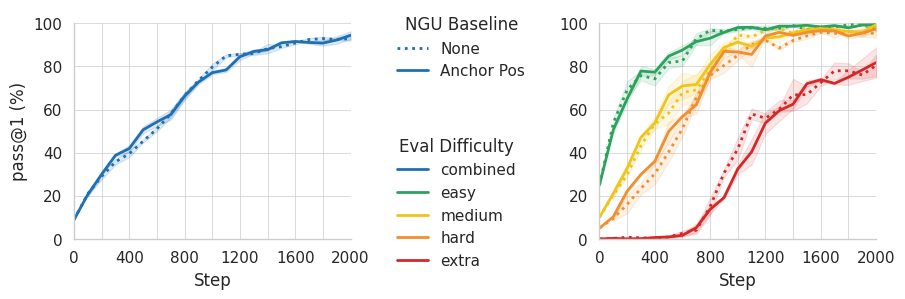

In [27]:
ANCHORNONE_GROUPS = [
    "ngu_comp_age_4",
    "ngu_comp4_count_anchorpos",
]
ANCHORNONE_GROUP_LABELS = {
    "ngu_comp_age_4": "None",
    "ngu_comp4_count_anchorpos": "Anchor Pos",
}
ANCHORNONE_LINESTYLES = {
    "None": ":",
    "Anchor Pos": "-",
}
ANCHORNONE_DRAW_ORDER = ["None", "Anchor Pos"]
ANCHORNONE_LEGEND_ORDER = ["None", "Anchor Pos"]

anchornone_runs_df, anchornone_run_by_id = collect_group_runs(ANCHORNONE_GROUPS)
anchornone_raw_history_df = download_run_histories(anchornone_runs_df, anchornone_run_by_id)

anchornone_metrics_df = extract_metrics(
    anchornone_raw_history_df[anchornone_raw_history_df["run_id"] != INITIAL_RUN_ID], METRICS
)
anchornone_initial_df = extract_initial_eval(anchornone_raw_history_df, ANCHORNONE_GROUPS, METRICS)
anchornone_plot_df = pd.concat([anchornone_initial_df, anchornone_metrics_df], ignore_index=True)
anchornone_plot_df["group"] = pd.Categorical(
    anchornone_plot_df["group"], categories=ANCHORNONE_GROUPS, ordered=True
)
anchornone_plot_df = anchornone_plot_df.sort_values(["group", "run_id", "metric", "Step"]).reset_index(drop=True)
anchornone_pass_at_1_df = anchornone_plot_df[anchornone_plot_df["metric"] == PLOT_METRIC_NAME].copy()
anchornone_pass_at_1_df["setting"] = anchornone_pass_at_1_df["group"].map(ANCHORNONE_GROUP_LABELS)

anchornone_difficulty_metrics_df = extract_metrics(
    anchornone_raw_history_df[anchornone_raw_history_df["run_id"] != INITIAL_RUN_ID], DIFFICULTY_METRICS
)
anchornone_difficulty_initial_df = pd.DataFrame(
    [
        {
            "group": group,
            "run_id": INITIAL_RUN_ID,
            "run_name": INITIAL_RUN_NAME,
            "metric": metric,
            "metric_key": DIFFICULTY_METRICS[metric],
            "Step": 0,
            "value": initial_value / 100,
            "raw_step": 0,
        }
        for group in ANCHORNONE_GROUPS
        for metric, initial_value in DIFFICULTY_INITIAL_VALUES.items()
    ]
)
anchornone_difficulty_plot_df = pd.concat(
    [anchornone_difficulty_initial_df, anchornone_difficulty_metrics_df], ignore_index=True
)
anchornone_difficulty_plot_df["group"] = pd.Categorical(
    anchornone_difficulty_plot_df["group"], categories=ANCHORNONE_GROUPS, ordered=True
)
anchornone_difficulty_plot_df["setting"] = pd.Categorical(
    anchornone_difficulty_plot_df["group"].map(ANCHORNONE_GROUP_LABELS),
    categories=[ANCHORNONE_GROUP_LABELS[g] for g in ANCHORNONE_GROUPS],
    ordered=True,
)
anchornone_difficulty_plot_df["metric"] = pd.Categorical(
    anchornone_difficulty_plot_df["metric"], categories=list(DIFFICULTY_METRICS), ordered=True
)
anchornone_difficulty_plot_df["pass_at_1_percent"] = anchornone_difficulty_plot_df["value"] * 100

_plot_linestyle_combined(
    anchornone_pass_at_1_df,
    anchornone_difficulty_plot_df,
    settings_draw_order=ANCHORNONE_DRAW_ORDER,
    settings_legend_order=ANCHORNONE_LEGEND_ORDER,
    linestyles=ANCHORNONE_LINESTYLES,
    base_color=BASELINE_COLOR,
    legend_title="NGU Baseline",
    output_pdf="gsm8k_pass_at_1_combined_ngu_anchor_vs_none.pdf",
)

## NGU Baseline vs NGU Max Age (difficulty-segmented)

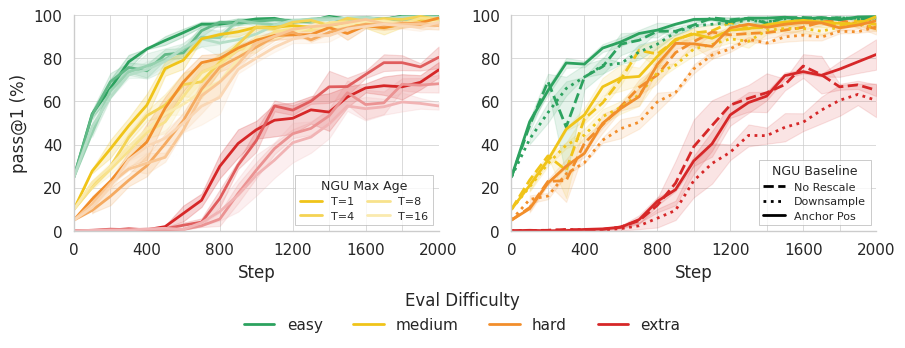

In [116]:
with mpl.rc_context(combined_rc):
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(10.35, 2.8), gridspec_kw={"wspace": 0.2}, constrained_layout=False
    )

    left_kwargs = dict(
        data=age_difficulty_plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="series",
        hue_order=age_series_order,
        palette=age_difficulty_palette,
        estimator="mean",
        err_style="band",
        ax=ax_left,
    )
    if tuple(int(part) for part in sns.__version__.split(".")[:2]) >= (0, 12):
        sns.lineplot(**left_kwargs, errorbar="se")
    else:
        sns.lineplot(**left_kwargs, ci="se")

    ax_left.set_xlabel("Step")
    ax_left.set_ylabel("pass@1 (%)")
    ax_left.set_xlim(0, MAX_STEP)
    ax_left.set_ylim(0, 100)
    ax_left.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_left.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_left.tick_params(axis="x", which="minor", length=0)
    ax_left.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_left)
    if ax_left.get_legend() is not None:
        ax_left.get_legend().remove()

    for setting in BASELINE_DRAW_ORDER:
        for metric in DIFFICULTY_METRICS:
            subset = baseline_difficulty_plot_df[
                (baseline_difficulty_plot_df["setting"] == setting)
                & (baseline_difficulty_plot_df["metric"] == metric)
            ]
            if subset.empty:
                continue
            agg = subset.groupby("Step")["pass_at_1_percent"].agg(mean="mean", sem="sem").reset_index()
            color = DIFFICULTY_BASE_COLORS[metric]
            ax_right.plot(
                agg["Step"], agg["mean"], color=color, linestyle=BASELINE_LINESTYLES[setting], linewidth=2.0
            )
            ax_right.fill_between(
                agg["Step"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"], color=color, alpha=0.12
            )

    ax_right.set_xlabel("Step")
    ax_right.set_ylabel("")
    ax_right.set_xlim(0, MAX_STEP)
    ax_right.set_ylim(0, 100)
    ax_right.set_xticks(range(0, MAX_STEP + 1, 400))
    ax_right.set_xticks(range(0, MAX_STEP + 1, 200), minor=True)
    ax_right.tick_params(axis="x", which="minor", length=0)
    ax_right.grid(which="minor", axis="x", linewidth=0.5)
    sns.despine(ax=ax_right)

    age_setting_order_local = [AGE_GROUP_LABELS[g] for g in AGE_GROUPS]
    age_shade_handles = [
        mpl.lines.Line2D(
            [0], [0],
            color=blend_with_white(DIFFICULTY_BASE_COLORS["medium"], shade),
            lw=2.0,
        )
        for shade in list(reversed(shade_strengths))
    ]
    age_legend = ax_left.legend(
        age_shade_handles,
        age_setting_order_local,
        title="NGU Max Age",
        frameon=True,
        facecolor="white",
        edgecolor="0.7",
        fancybox=False,
        fontsize=8,
        title_fontsize=9,
        loc="lower right",
        ncol=2,
        columnspacing=1.2,
        labelspacing=0.4,
    )
    age_legend.get_frame().set_linewidth(0.6)

    baseline_handles = [
        mpl.lines.Line2D([0], [0], color="black", linestyle=BASELINE_LINESTYLES[s], lw=2.0)
        for s in BASELINE_LEGEND_ORDER
    ]
    baseline_legend = ax_right.legend(
        baseline_handles,
        BASELINE_LEGEND_ORDER,
        title="NGU Baseline",
        frameon=True,
        facecolor="white",
        edgecolor="0.7",
        fancybox=False,
        fontsize=8,
        title_fontsize=9,
        loc="lower right",
        labelspacing=0.4,
    )
    baseline_legend.get_frame().set_linewidth(0.6)

    diff_handles = [
        mpl.lines.Line2D([0], [0], color=DIFFICULTY_BASE_COLORS[m], lw=2.0) for m in DIFFICULTY_METRICS
    ]
    fig.legend(
        diff_handles,
        list(DIFFICULTY_METRICS),
        title="Eval Difficulty",
        frameon=False,
        loc="lower center",
        ncol=len(DIFFICULTY_METRICS),
        bbox_to_anchor=(0.5, -0.30),
    )

    fig.savefig(OUTPUT_DIR / "gsm8k_pass_at_1_difficulty_baseline_vs_max_age.pdf", bbox_inches="tight")